In [5]:
import os

for root, dirs, files in os.walk(r'C:\Users\priya\Downloads'):
    for file in files:
        if 'train' in file.lower() and file.lower().endswith('.csv'):
            print(os.path.join(root, file))
            import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\priya\Downloads\archive (7)\train (1).csv')

# Select the most relevant columns for a simple regression model
cols = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'OverallQual',
        'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'Neighborhood', 'SalePrice']
df = df[cols]

print(df.shape)
df.head()
print(df.isnull().sum())
# Numeric columns -> fill with median
num_cols = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'OverallQual',
            'YearBuilt', 'GarageCars', 'TotalBsmtSF']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical -> fill with mode
df['Neighborhood'] = df['Neighborhood'].fillna(df['Neighborhood'].mode()[0])

print("Missing values after fix:")
print(df.isnull().sum())
df_encoded = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)
print(df_encoded.shape)
df_encoded.head()

C:\Users\priya\Downloads\archive (6)\train (1).csv
C:\Users\priya\Downloads\archive (7)\train (1).csv
(1460, 9)
GrLivArea       0
BedroomAbvGr    0
FullBath        0
OverallQual     0
YearBuilt       0
GarageCars      0
TotalBsmtSF     0
Neighborhood    0
SalePrice       0
dtype: int64
Missing values after fix:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
OverallQual     0
YearBuilt       0
GarageCars      0
TotalBsmtSF     0
Neighborhood    0
SalePrice       0
dtype: int64
(1460, 32)


,GrLivArea,BedroomAbvGr,FullBath,OverallQual,YearBuilt,GarageCars,TotalBsmtSF,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,3,2,7,2003,2,856,208500,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1262,3,2,6,1976,2,1262,181500,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1786,3,2,7,2001,2,920,223500,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1717,3,1,7,1915,3,756,140000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2198,4,2,8,2000,3,1145,250000,False,False,...,True,False,False,False,False,False,False,False,False,False


In [6]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1168
Testing rows: 292


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 22265.27
RMSE: 36076.5
R²  : 0.8303


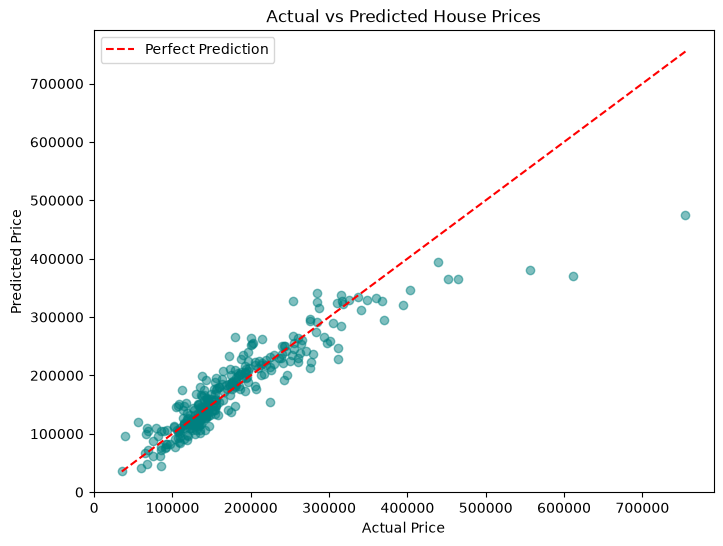

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df)
## Conclusion

This Linear Regression model predicts house sale prices using 8 key features (living area, bedrooms, bathrooms, overall quality, year built, garage capacity, basement size, and neighborhood).

**Model Performance:**
- R² = 0.83 — the model explains ~83% of the variation in house prices
- MAE = $22,265 — average prediction error
- RMSE = $36,076

**Key Insights:**
- Overall quality, living area, and garage capacity are the strongest positive predictors of price
- Neighborhood matters significantly — premium areas like StoneBr, NridgHt, and NoRidge add tens of thousands of dollars in value
- A simple 8-feature model already captures most of the price variation, though the full 81-column dataset would likely improve accuracy further

**Real-world application:** This type of model could help real estate platforms provide instant price estimates, assist buyers in evaluating whether a listing is fairly priced, or help sellers set competitive asking prices.

                 Feature   Coefficient
28  Neighborhood_StoneBr  74639.967469
22  Neighborhood_NridgHt  73020.057633
21  Neighborhood_NoRidge  71590.859871
30  Neighborhood_Veenker  63619.166906
10  Neighborhood_ClearCr  51672.454647
12  Neighborhood_Crawfor  48011.023004
29   Neighborhood_Timber  41021.378942
27  Neighborhood_Somerst  31126.869253
11  Neighborhood_CollgCr  25859.990146
9   Neighborhood_BrkSide  24943.517901
25   Neighborhood_Sawyer  23336.885059
18    Neighborhood_NAmes  20081.444043
14  Neighborhood_Gilbert  19365.229389
26  Neighborhood_SawyerW  17209.386663
17  Neighborhood_Mitchel  16120.691305
24    Neighborhood_SWISU  16090.513609
3            OverallQual  15379.734971
20   Neighborhood_NWAmes  15119.186128
15   Neighborhood_IDOTRR  15065.013130
5             GarageCars  12510.462455
13  Neighborhood_Edwards  11783.521755
23  Neighborhood_OldTown   7957.760784
16  Neighborhood_MeadowV   7479.182862
19  Neighborhood_NPkVill   2724.468071
4              YearBuilt 

In [11]:
import os
print(os.getcwd())
print([f for f in os.listdir() if f.endswith('.ipynb')])

c:\Users\priya\Downloads\archive (7)
['house prediction.ipynb']


In [13]:
import os
for root, dirs, files in os.walk(r'C:\Users\priya\Downloads'):
    for file in files:
        if file.endswith('.ipynb'):
            print(os.path.join(root, file))
            dir /s /b "C:\Users\priya\Downloads\*.ipynb"

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3973048074.py, line 6)